<a href="https://colab.research.google.com/github/mushrafi88/MSE_510/blob/main/Midterm_Spring2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mushrafi Munim Sushmit

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Part 1. Computational modeling

## 1.1 Capacitor discharging in an RC circuit (warm up)

$$RC\frac{dV}{dt}+V=0$$

$R = 1$ Ohm

$C= 1$ F

$V(t=0)=1$



**Q1. Implement 3 time-stepping methods**

Write code to solve $V(t)$ on $t∈[0,T]$ using step size h with:

1) Explicit Euler

2) Runge–Kutta 2nd order (midpoint method)

3) Runge–Kutta 4th order

Use $T=10$ start with $h=1$, then decrease a step to $h=0.1$. Test also intermediate values for $h$

In [ ]:
#fill the gaps in the code below

#problem definition
def rc_rhs(t, V, R=1, C=1):
  return -V/(R*C)

#exact solution(ground truth)
def exact_rc(t, R=1, C=1, v0=1):
  return v0*np.exp(-t/(R*C))


def rk2_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + 0.5*h, y + 0.5*h*k1)
    return y + h * k2


def rk4_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + 0.5*h, y + 0.5*h*k1)
    k3 = f(t + 0.5*h, y + 0.5*h*k2)
    k4 = f(t + h, y + h*k3)

    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

def euler_step(f, t, y, h):
    return y + h * f(t, y)

# -----------------------------
# Simulation function
# -----------------------------

def solve_ode(f, y0, T, h, method):
    N = int(T/h)
    t = np.linspace(0, T, N+1)
    y = np.zeros(N+1)
    y[0] = y0

    for n in range(N):
        y[n+1] = method(f, t[n], y[n], h)

    return t, y

In [ ]:
T = 10
h = 1     # different
v0 = 1.0 #V(t=0) = 1

t_e, y_e = solve_ode(rc_rhs, v0, T, h, euler_step)
#t_t2, y_t2 = solve_ode(rc_rhs, y0, T, h, taylor2_step)

#calculate the same for the RK2 and RK4

t_rk2, y_rk2 = solve_ode(rc_rhs, v0, T, h, rk2_step)
t_rk4, y_rk4 = solve_ode(rc_rhs, v0, T, h, rk4_step)


# Exact solution of the ODE (ground truth)
t_exact = np.linspace(0, T, 500)
y_exact = exact_rc(t_exact)

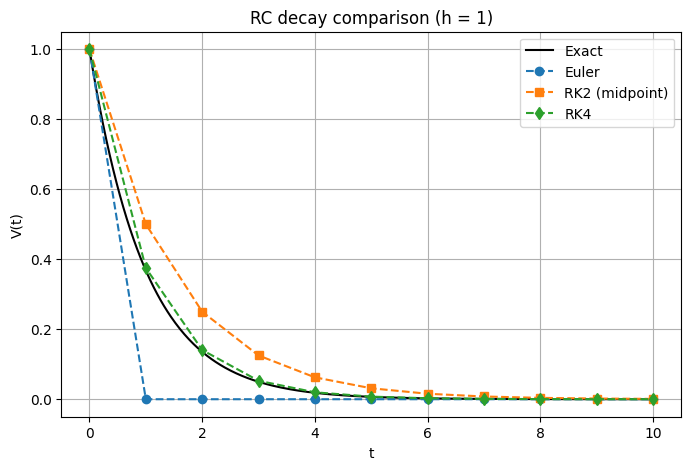

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Exact solution
plt.plot(t_exact, y_exact, 'k', label="Exact")

# Numerical solutions
plt.plot(t_e, y_e, 'o--', label="Euler")
plt.plot(t_rk2, y_rk2, 's--', label="RK2 (midpoint)")
plt.plot(t_rk4, y_rk4, 'd--', label="RK4")

plt.xlabel("t")
plt.ylabel("V(t)")
plt.title(f"RC decay comparison (h = {h})")

plt.legend()
plt.grid(True)

plt.show()

**Q2. Compute the solutions**

1) Compute the numerical solutions for the different methods and $h$ (use at least 3-5 different $h$)
2) Plot the solutions
3) Compare them with the exact solution on the same plot

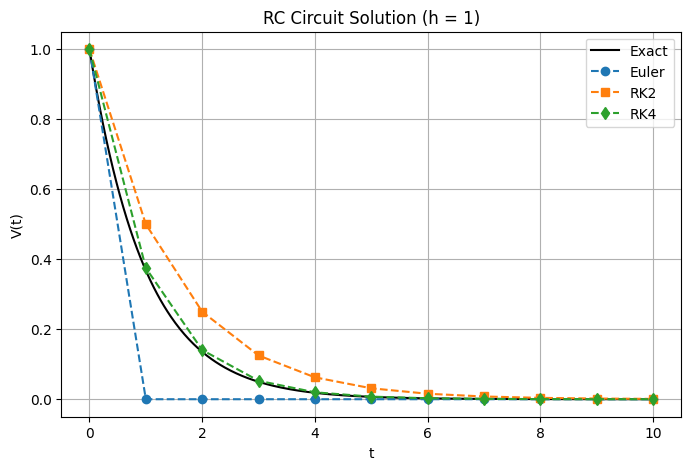

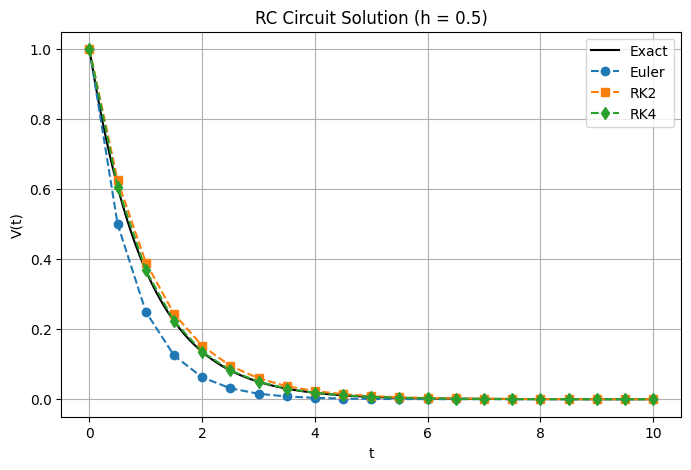

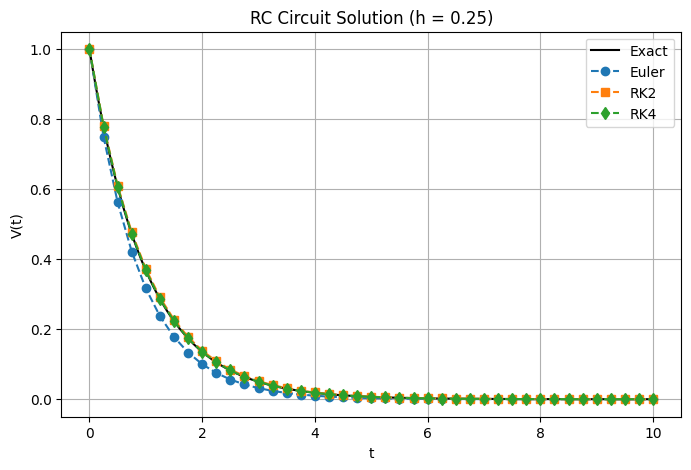

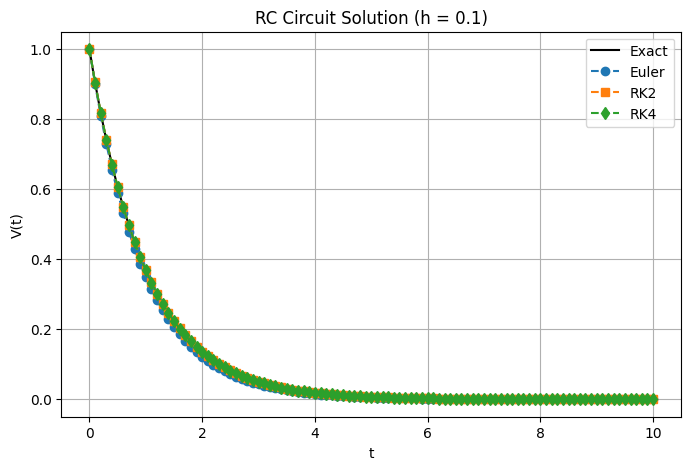

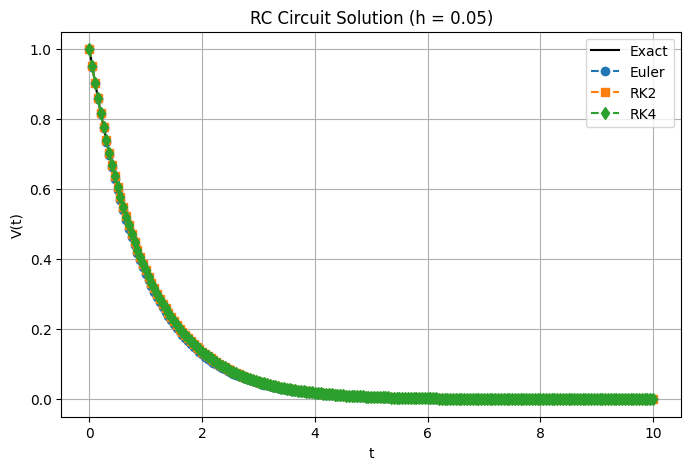

In [ ]:
#your code
import numpy as np
import matplotlib.pyplot as plt

T = 10
v0 = 1

# step sizes
hs = [1, 0.5, 0.25, 0.1, 0.05]

# exact solution
t_exact = np.linspace(0, T, 500)
y_exact = exact_rc(t_exact)

for h in hs:

    # compute numerical solutions
    t_e, y_e = solve_ode(rc_rhs, v0, T, h, euler_step)
    t_rk2, y_rk2 = solve_ode(rc_rhs, v0, T, h, rk2_step)
    t_rk4, y_rk4 = solve_ode(rc_rhs, v0, T, h, rk4_step)

    # plot
    plt.figure(figsize=(8,5))

    plt.plot(t_exact, y_exact, 'k', label="Exact")
    plt.plot(t_e, y_e, 'o--', label="Euler")
    plt.plot(t_rk2, y_rk2, 's--', label="RK2")
    plt.plot(t_rk4, y_rk4, 'd--', label="RK4")

    plt.title(f"RC Circuit Solution (h = {h})")
    plt.xlabel("t")
    plt.ylabel("V(t)")
    plt.legend()
    plt.grid(True)

    plt.show()

**Q3. Study how error depends on step size**

For each method and each step size compute RMS error over the whole interval:

$RMS_h=\sqrt{\frac{1}{N+1}\sum_{n=1}^{N}{(V_{est}(t_n)-V_{exact}(t_n))^2}}$


1) Plot RMS error vs step size (log–log) for all three methods on the same graph.

2) For each method, estimate how fast the error decreases when $h$ decreases.



$$p=\frac{\log(RMS_{h1}/RMS_{h2})}{\log{(h_1/h_2)}}$$

$p$ tells you the order of the method.

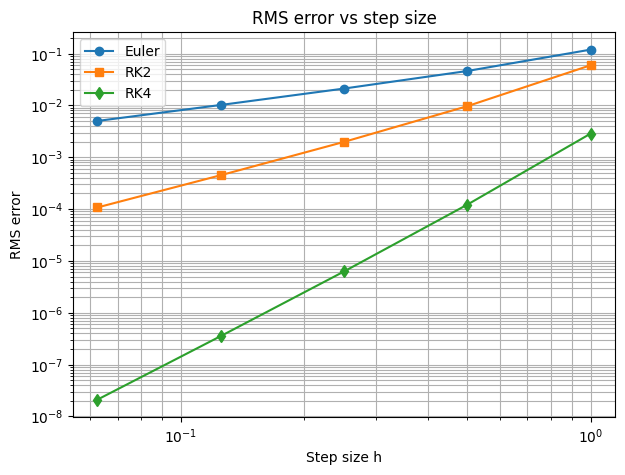

In [ ]:
T = 10
v0 = 1

hs = np.array([1, 0.5, 0.25, 0.125, 0.0625])

rms_euler = []
rms_rk2 = []
rms_rk4 = []

for h in hs:

    t_e, y_e = solve_ode(rc_rhs, v0, T, h, euler_step)
    t_rk2, y_rk2 = solve_ode(rc_rhs, v0, T, h, rk2_step)
    t_rk4, y_rk4 = solve_ode(rc_rhs, v0, T, h, rk4_step)

    exact_e = exact_rc(t_e)
    exact_rk2 = exact_rc(t_rk2)
    exact_rk4 = exact_rc(t_rk4)

    N = len(t_e) - 1

    rms1 = np.sqrt((1/(N+1)) * np.sum((y_e - exact_e)**2))
    rms2 = np.sqrt((1/(N+1)) * np.sum((y_rk2 - exact_rk2)**2))
    rms3 = np.sqrt((1/(N+1)) * np.sum((y_rk4 - exact_rk4)**2))

    rms_euler.append(rms1)
    rms_rk2.append(rms2)
    rms_rk4.append(rms3)

rms_euler = np.array(rms_euler)
rms_rk2 = np.array(rms_rk2)
rms_rk4 = np.array(rms_rk4)

plt.figure(figsize=(7,5))

plt.loglog(hs, rms_euler, 'o-', label='Euler')
plt.loglog(hs, rms_rk2, 's-', label='RK2')
plt.loglog(hs, rms_rk4, 'd-', label='RK4')

plt.xlabel("Step size h")
plt.ylabel("RMS error")
plt.title("RMS error vs step size")

plt.grid(True, which="both")
plt.legend()

plt.show()

In [ ]:
def estimate_order(rms, hs):

    orders = []

    for i in range(len(hs)-1):

        p = np.log(rms[i]/rms[i+1]) / np.log(hs[i]/hs[i+1])
        orders.append(p)

    return np.array(orders)


p_euler = estimate_order(rms_euler, hs)
p_rk2 = estimate_order(rms_rk2, hs)
p_rk4 = estimate_order(rms_rk4, hs)

print("Euler order:", p_euler)
print("RK2 order:", p_rk2)
print("RK4 order:", p_rk4)

Euler order: [1.3691932  1.12597415 1.05208809 1.0237693 ]
RK2 order: [2.62214559 2.28924632 2.13603624 2.06559641]
RK4 order: [4.55166274 4.28371635 4.14195133 4.07083134]


## 1.2.  Nonlinear Pendulum

Consider a simple pendulum of length $L$ in gravitational field $g$.

Motion equation:

$$\frac{d^2\theta}{dt^2}+\frac{g}{L}\sin{\theta}=0$$
$$\omega = \frac{d\theta}{dt}$$

$$\frac{d\omega}{dt}= -\frac{g}{L}\sin{\theta}$$

Use:

$g=9.81$ m/s$^2$,
$L=1$ m,
$\theta(t=0)=1.2$ rad,
$\omega(t=0)=0$

Make all simulation for:
$t \in [0, 20]$


**Q2.1 Numerical solutions**

- Solve this equation for $\theta(t)$ numerically with different methods and for the different step size as above.
- Analyse the results

In [ ]:
#your code
import numpy as np
import matplotlib.pyplot as plt

g = 9.81
L = 1

def pendulum_rhs(t, y):

    theta = y[0]
    omega = y[1]

    dtheta = omega
    domega = -(g/L) * np.sin(theta)

    return np.array([dtheta, domega])

y0 = np.array([1.2, 0.0])   # theta(0), omega(0)
T = 20

In [ ]:
def solve_ode(f, y0, T, h, method):

    N = int(T/h)

    t = np.linspace(0, T, N+1)

    y = np.zeros((N+1, len(y0)))
    y[0] = y0

    for n in range(N):

        y[n+1] = method(f, t[n], y[n], h)

    return t, y

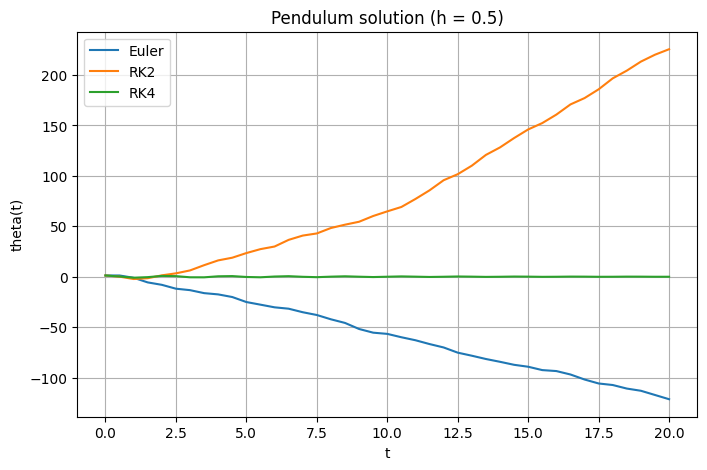

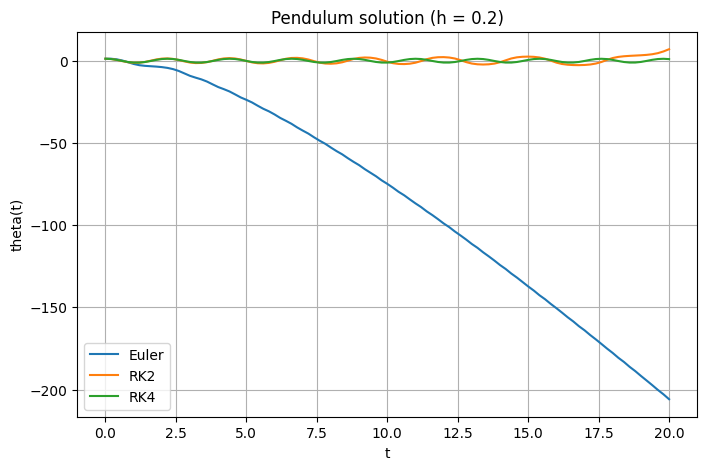

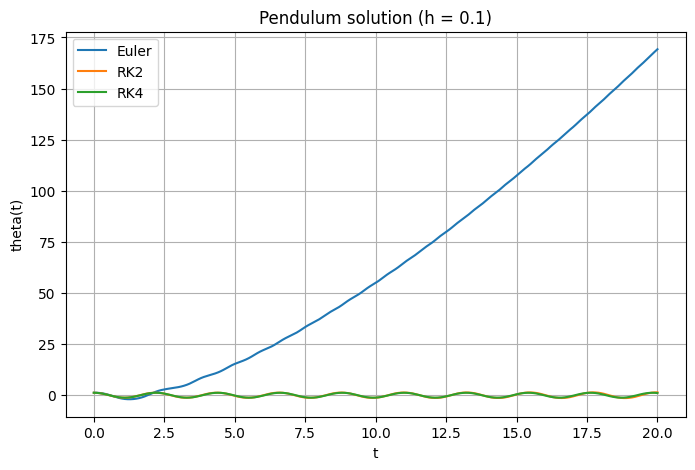

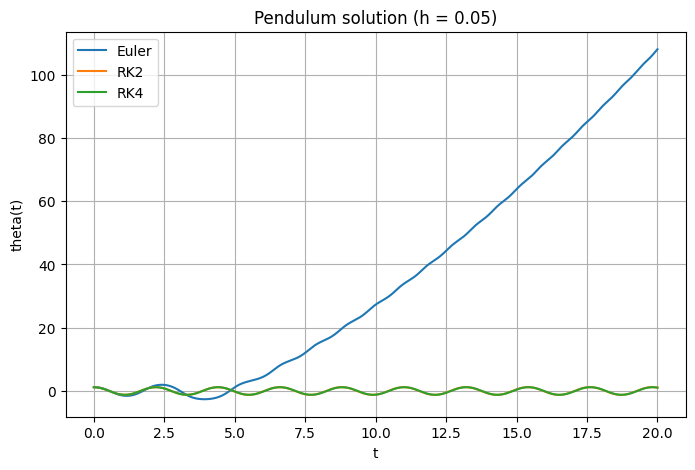

In [ ]:
hs = [0.5, 0.2, 0.1, 0.05]

for h in hs:
    t_e, y_e = solve_ode(pendulum_rhs, y0, T, h, euler_step)
    t_rk2, y_rk2 = solve_ode(pendulum_rhs, y0, T, h, rk2_step)
    t_rk4, y_rk4 = solve_ode(pendulum_rhs, y0, T, h, rk4_step)

    plt.figure(figsize=(8,5))

    plt.plot(t_e, y_e[:,0], label="Euler")
    plt.plot(t_rk2, y_rk2[:,0], label="RK2")
    plt.plot(t_rk4, y_rk4[:,0], label="RK4")

    plt.xlabel("t")
    plt.ylabel("theta(t)")
    plt.title(f"Pendulum solution (h = {h})")

    plt.legend()
    plt.grid()

    plt.show()

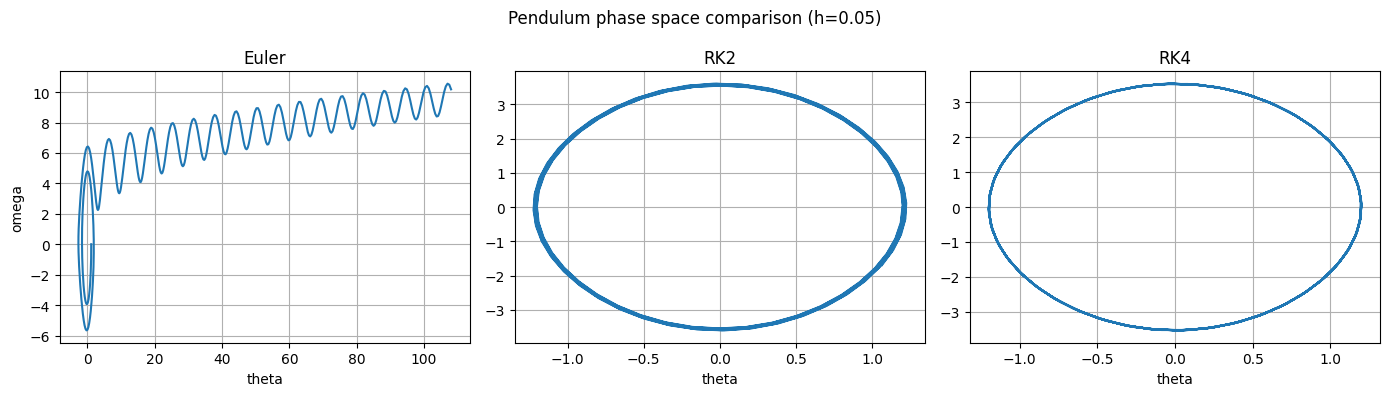

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(14,4))

axes[0].plot(y_e[:,0], y_e[:,1])
axes[0].set_title("Euler")
axes[0].set_xlabel("theta")
axes[0].set_ylabel("omega")
axes[0].grid()

axes[1].plot(y_rk2[:,0], y_rk2[:,1])
axes[1].set_title("RK2")
axes[1].set_xlabel("theta")
axes[1].grid()

axes[2].plot(y_rk4[:,0], y_rk4[:,1])
axes[2].set_title("RK4")
axes[2].set_xlabel("theta")
axes[2].grid()

plt.suptitle(f"Pendulum phase space comparison (h={h})")
plt.tight_layout()
plt.show()

**Q2.2 Nonlinear vs Linear Model**

For small angles we may use linear approximation $\sin\theta \approx \theta$:

$$\frac{d^2\theta}{dt^2}+\frac{g}{L}\theta=0$$

- Solve this equation analytically and numerically
- Compare linear and nonlinear models for the small and large angles
- Suggest a quantitative criterion for when the approximation is acceptable and determine the corresponding limit on $\theta_{threshold}$.

For the **small-angle approximation**, replace (\sin\theta) with (\theta):

$$
\frac{d^2\theta}{dt^2}+\frac{g}{L}\theta=0
$$


This is a **simple harmonic oscillator**.

---

# Analytical solution (linear model)

Let

$$
\omega_0=\sqrt{\frac{g}{L}}
$$

With initial conditions

$$
\theta(0)=\theta_0,\qquad \dot{\theta}(0)=\omega_0^{init}
$$

the solution is

$$
\theta(t)=\theta_0\cos(\omega_0 t)+\frac{\omega_0^{init}}{\omega_0}\sin(\omega_0 t)
$$

For our case $(\omega(0)=0)$:

$$
\theta(t)=\theta_0\cos(\omega_0 t)
$$

---



In [ ]:
# your code
def pendulum_linear_rhs(t, y):

    theta = y[0]
    omega = y[1]

    dtheta = omega
    domega = -(g/L)*theta

    return np.array([dtheta, domega])


In [ ]:
omega0 = np.sqrt(g/L)

def linear_exact(t, theta0, omega0_init):

    return theta0*np.cos(omega0*t) + (omega0_init/omega0)*np.sin(omega0*t)

In [ ]:
theta0_small = 0.1
theta0_large = 1.2

y0_small = np.array([theta0_small,0])
y0_large = np.array([theta0_large,0])

h = 0.05

t_nl_s, y_nl_s = solve_ode(pendulum_rhs, y0_small, T, h, rk4_step)
t_lin_s, y_lin_s = solve_ode(pendulum_linear_rhs, y0_small, T, h, rk4_step)

t_nl_l, y_nl_l = solve_ode(pendulum_rhs, y0_large, T, h, rk4_step)
t_lin_l, y_lin_l = solve_ode(pendulum_linear_rhs, y0_large, T, h, rk4_step)

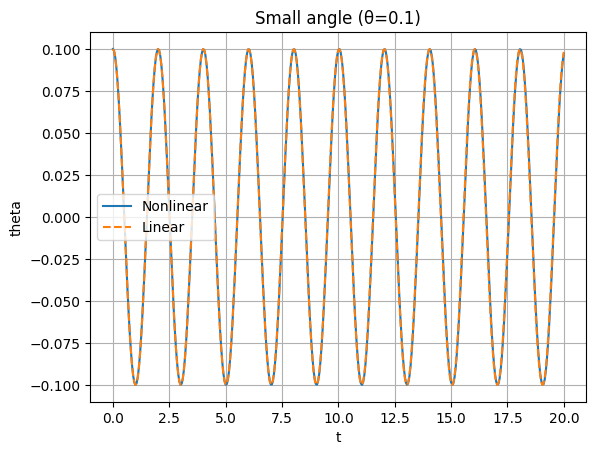

In [ ]:
plt.figure()

plt.plot(t_nl_s, y_nl_s[:,0], label="Nonlinear")
plt.plot(t_lin_s, y_lin_s[:,0],'--', label="Linear")

plt.title("Small angle (θ=0.1)")
plt.xlabel("t")
plt.ylabel("theta")

plt.legend()
plt.grid()
plt.show()

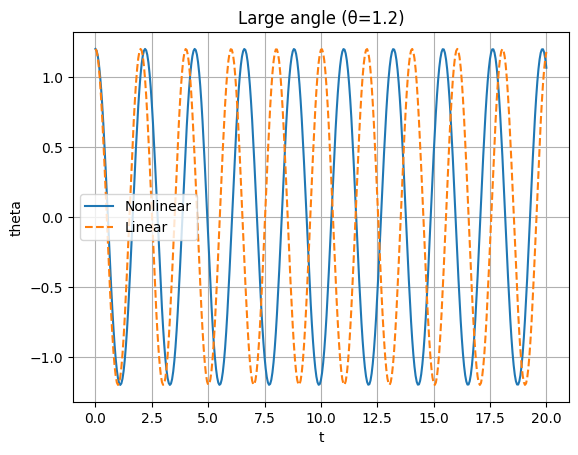

In [ ]:
plt.figure()

plt.plot(t_nl_l, y_nl_l[:,0], label="Nonlinear")
plt.plot(t_lin_l, y_lin_l[:,0],'--', label="Linear")

plt.title("Large angle (θ=1.2)")
plt.xlabel("t")
plt.ylabel("theta")

plt.legend()
plt.grid()
plt.show()

For small angles when the $\sin(\theta)$ and $\theta$ become equal, we can expect the linear nature.

So we choose $ \theta \in [0,1.2] $
and try to find the optimal value by taking the difference between them

In [ ]:
theta = np.linspace(1e-16,10,1000)

err = np.abs(np.sin(theta)-theta)/theta
err[0]=0

theta_threshold = theta[np.where(err<0.01)[0][-1]]

print(theta_threshold)

0.24024024024024035


$ \theta < 0.2 $ (~11°) --> linear model threshold

# Part 2. Data-Driven Model Discovery with Symbolic Regression

In this task you will use symbolic regression to recover governing equations from numerically generated pendulum data.

Symbolic regression is performed using the [PySr](https://astroautomata.com/PySR/v1.5.9/api.html) python package.

In [ ]:
!pip install -U pysr

In [ ]:
from pysr import PySRRegressor

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [ ]:
#exampl of the pysr regressor, more details in PySr documentation documentation

model = PySRRegressor(
    niterations=30,
    binary_operators=["+", "*", "/", "-"], #extend if require
    unary_operators=["cos", "exp", "sin"], #extend and refine if require
)

**Q.1 Symbolic Regression with PySR**

- Generate datasets for the small- and large-angle pendulum models from Part 1.2 (obtain $\theta(t)$)

- Create and refine a PySR model (define appropriate unary and binary operators, etc.; see example above and pysr documentation).

- Fit symbolic models separately for:
  - small-angle dataset
  - large-angle dataset
- Analyse and compare the suggested symbolic models.
  - Does each PySR regressor recover: $\frac{d\omega}{dt}= -\frac{g}{L}\theta$ for small angles?
  - Does it recover $\frac{d\omega}{dt}= -\frac{g}{L}\sin{\theta}$ for large angles?
- Do the discovered models generalize to larger amplitudes?

- What criteria does PySR use to select the optimal model?

In [ ]:
#your code

## DATASET Generation

import numpy as np

g = 9.81
L = 1

def pendulum_rhs(t, y):
    theta, omega = y
    return np.array([omega, -(g/L)*np.sin(theta)])

def generate_dataset(theta0, T=20, h=0.02):

    y0 = np.array([theta0,0])
    t, y = solve_ode(pendulum_rhs, y0, T, h, rk4_step)

    theta = y[:,0]
    omega = y[:,1]

    domega = -(g/L)*np.sin(theta)

    X = np.column_stack([theta, omega])
    y_target = domega

    return X, y_target

X_small, y_small = generate_dataset(theta0=0.05)
X_large, y_large = generate_dataset(theta0=1.2)

In [ ]:
# PYSR REGRESSION

from pysr import PySRRegressor

model_large = PySRRegressor(
    niterations=100,
    binary_operators=["+", "-", "*"],
    unary_operators=[
        "sin",
        "cos"
    ],
    populations=20,
    maxsize=20,
    model_selection="best",
    loss="loss(x,y) = (x - y)^2",
    verbosity=1
)

# large angle
model_large_eq = model_large.fit(X_large, y_large)

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.060e+04
Progress: 133 / 2000 total iterations (6.650%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.897e+01  0.000e+00  y = -0.086114
3           2.079e-01  2.731e+00  y = x₀ * -8.1318
4           2.110e-13  2.762e+01  y = sin(x₀) * -9.81
8           1.514e-13  8.303e-02  y = (sin(x₀) * -9.81) - (x₀ * -1.8477e-06)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 2.360e+04
Progress: 265 / 2000 total iterations (13.250%)
════════════════════════════════════════════════════════════════════════════════════════

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 2.150e+04
Progress: 1901 / 2000 total iterations (95.050%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.897e+01  0.000e+00  y = -0.086114
3           2.079e-01  2.731e+00  y = x₀ * -8.1318
4           1.201e-13  2.818e+01  y = sin(x₀) * -9.81
6           1.142e-13  2.524e-02  y = (sin(x₀) * 1) * -9.81
9           1.116e-13  7.652e-03  y = -9.4912 * ((sin(x₀) * 0.033588) + sin(x₀))
11          1.090e-13  1.183e-02  y = ((sin(x₀ + 1.0609e-07) * 0.033467) + sin(x₀)) * -9.492...
                                      3
13          1.086e-13  1.889e-03  y = (sin(x₀) + (0.033467 * ((8.4237e-08 * x₀) + sin(x₀))))...
                                       * -9.4923
15          1.080e-13  2.608e-03  y = ((sin(x₀ + (cos(sin(x₁)) * 2.2571e-07)) * 0.03346

In [ ]:
model_small = PySRRegressor(
    niterations=100,
    binary_operators=["+", "*"],
    unary_operators=[],
    populations=20,
    maxsize=20,
    model_selection="best",
    loss="loss(x,y) = (x - y)^2",
    verbosity=1
)

# small angle
model_small_eq = model_small.fit(X_small, y_small)

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 5.580e+04
Progress: 368 / 2000 total iterations (18.400%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.200e-01  0.000e+00  y = 0.0010196
3           1.303e-09  9.169e+00  y = x₀ * -9.8069
5           1.302e-09  1.687e-05  y = (x₀ * -9.8069) + -1.0801e-07
7           1.964e-10  9.460e-01  y = ((x₀ * x₀) + -9.8088) * x₀
9           3.788e-12  1.974e+00  y = x₀ * (((x₀ * 1.5466) * x₀) + -9.8098)
15          1.079e-12  2.093e-01  y = (((((x₀ * 0.67906) * x₀) + -4.592) * x₀) + (x₀ * 0.396...
                                      37)) * 2.3381
17          1.233e-15  3.387e+00  y = ((x₀ + (x₀ + x₀)) + ((x₀ * (x₁ + (x₁ * -0.94896))) * x...
                                      ₁)) * -3.2686
────────────────────────────────────────────────────────────

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 5.750e+04
Progress: 1722 / 2000 total iterations (86.100%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.200e-01  0.000e+00  y = 0.0010196
3           1.303e-09  9.169e+00  y = x₀ * -9.8069
5           1.302e-09  1.687e-05  y = (x₀ * -9.8069) + -1.0801e-07
7           1.964e-10  9.460e-01  y = ((x₀ * x₀) + -9.8088) * x₀
9           3.788e-12  1.974e+00  y = x₀ * (((x₀ * 1.5466) * x₀) + -9.8098)
15          1.079e-12  2.093e-01  y = (((((x₀ * 0.67906) * x₀) + -4.592) * x₀) + (x₀ * 0.396...
                                      37)) * 2.3381
17          1.140e-15  3.426e+00  y = ((x₀ + x₀) + (x₀ + (x₀ * ((x₁ + (x₁ * -0.94896)) * x₁)...
                                      ))) * -3.2686
19          2.606e-16  7.379e-01  y = (((x₁ * -0.02778) * (

In [ ]:
def get_best_equation_by_score(model):
    eq_table = model.equations_

    # row with maximum PySR score
    best_row = eq_table.loc[eq_table["score"].idxmax()]

    return {
        "equation": best_row["equation"],
        "score": float(best_row["score"]),
        "loss": float(best_row["loss"]),
        "complexity": int(best_row["complexity"]),
    }

In [ ]:
best_small = get_best_equation_by_score(model_small_eq)

print("Best Small-Angle model (by score)")
print("Equation   :", best_small["equation"])
print("Score      :", best_small["score"])
print("Loss       :", best_small["loss"])
print("Complexity :", best_small["complexity"])

Best Small-Angle model (by score)
Equation   : x0 * -9.806938
Score      : 9.169205659521076
Loss       : 1.3025161e-09
Complexity : 3


In [ ]:
best_large = get_best_equation_by_score(model_large_eq)

print("\nBest Large-Angle model (by score)")
print("Equation   :", best_large["equation"])
print("Score      :", best_large["score"])
print("Loss       :", best_large["loss"])
print("Complexity :", best_large["complexity"])


Best Large-Angle model (by score)
Equation   : sin(x0) * -9.81
Score      : 28.229935533431668
Loss       : 1.1422616e-13
Complexity : 4


**Q.2 LLM-assisted model selection**

In this task, you will integrate a Large Language Model (Gemini) as a scientific reasoning assistant to evaluate the results of symbolic regression and select the most physically grounded model.

In the previous part, the PySR regressor generated several candidate symbolic expressions describing the dependence of the system. You analyzed the criteria used for selecting the best model based on statistical metrics.

Here, we are going to extent this analysis by incorporating an LLM assistant capable of introducing additional physical reasoning criteria. The goal is to evaluate whether the discovered symbolic models are not only statistically optimal but also physically consistent with known physical laws.


1. Construct a prompt that includes:
  - Short description of the pendulum system
  - Some physical assumptions and constraits
  - Candidate model

2. Design a structured JSON response scheme that Gemini must follow
  - Model index
  - Physics consistency score
  - Flags for potential issues (e.g., symmetry violation, physics violation, etc.)
  
  These criteria are approximate you may propose your own criteria and scheme.
  
3. Call [Gemini API](https://aistudio.google.com/welcome?utm_source=google&utm_medium=cpc&utm_campaign=Cloud-SS-DR-AIS-FY26-global-gsem-1713578&utm_content=text-ad&utm_term=KW_gemini%20api&gad_source=1&gad_campaignid=23417416052&gbraid=0AAAAACn9t67Ls8VCFt52ymzxENtBzpu6I&gclid=Cj0KCQiAtfXMBhDzARIsAJ0jp3BP0TpgyH5ipTdbfM34RlJBObFChM-KAt0veBn04Rh8gTNtYQLYUikaAoqSEALw_wcB) and define the LLM based criteria for the each of the candidate model

4. Define a combined selection criterion, for example: $\alpha*PySR_{score} + (1- \alpha)*LLM_{score}$ and choose the best model.

- Analyse the result, test different joint criteria, different weight ration between the PySr_score and LLM_score.  


In [ ]:
#import gemini api
from google import genai

#your api key.
#REMOVE YOUR KEY BEFORE SUBMISSION!
api_key = ""

client = genai.Client(api_key=api_key, http_options={'api_version': 'v1beta'})

In [ ]:
#the simplest query as example
resp = client.models.generate_content(
        model='gemini-2.5-flash',
        contents="Explain why sin(theta) ≈ theta for small angles."
    )

print(resp)

sdk_http_response=HttpResponse(
  headers=<dict len=10>
) candidates=[Candidate(
  content=Content(
    parts=[
      Part(
        text="""The approximation $\sin(\theta) \approx \theta$ for small angles is a fundamental concept in mathematics and physics. Here's why it holds true, explained through different perspectives:

**1. Geometric Intuition (Unit Circle)**

Imagine a unit circle (a circle with radius $r=1$) centered at the origin.
*   Draw an angle $\theta$ (in radians) from the positive x-axis.
*   The point where the angle intersects the circle is $(\cos\theta, \sin\theta)$.
*   The vertical distance from this point to the x-axis is $\sin\theta$. This is the "opposite" side of the right triangle formed.
*   The **arc length** along the circle from $(1,0)$ to $(\cos\theta, \sin\theta)$ is given by $s = r\theta$. Since $r=1$, the arc length is simply $\theta$.

Now, consider what happens when $\theta$ is very small:
*   The point $(\cos\theta, \sin\theta)$ is very close to $(1

As you can see, an unstructured response is inconvenient to integrate into an explainable workflow. Therefore, we require a structured JSON schema.

In [ ]:
#your code

from google import genai

client = genai.Client(api_key=api_key, http_options={"api_version": "v1beta"})

prompt = """
You are a scientific reasoning assistant evaluating symbolic models for a physical system.

System description:
We study the motion of a simple pendulum of length L = 1 m in a gravitational field g = 9.81 m/s².

The physical governing equations are:

dθ/dt = ω
dω/dt = -(g/L) sin(θ)

For small oscillations the linear approximation applies:

dω/dt ≈ -(g/L) θ

Goal:
Evaluate whether the candidate symbolic model below is physically consistent with the pendulum dynamics.

Physical assumptions and constraints:
1. The restoring force must oppose the displacement (acceleration should point toward equilibrium).
2. For an ideal pendulum the angular acceleration depends primarily on θ, not directly on ω.
3. The restoring force should be approximately linear for very small angles.
4. For large angles the restoring force should be bounded and sinusoidal-like.
5. The coefficient of the restoring term should be close to g/L ≈ 9.81.
6. The model should respect symmetry of the pendulum: the restoring term should change sign when θ changes sign.

Candidate symbolic model for angular acceleration:

dω/dt = -9.81*sin(θ)

Task:
Evaluate this candidate model using physical reasoning and determine whether it is consistent with the expected pendulum physics.
"""

resp = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt
)

print(resp.text)

Let's evaluate the candidate symbolic model `dω/dt = -9.81*sin(θ)` against each physical assumption and constraint.

First, recall the given physical governing equations for the pendulum:
*   Full non-linear: `dω/dt = -(g/L) sin(θ)`
*   Linear approximation (small angles): `dω/dt ≈ -(g/L) θ`
*   Given `L = 1 m` and `g = 9.81 m/s²`, so `g/L = 9.81 / 1 = 9.81`.

Therefore, the exact non-linear equation for this specific pendulum is `dω/dt = -9.81*sin(θ)`.

Now, let's check the candidate model: `dω/dt = -9.81*sin(θ)`.

---

**Evaluation against assumptions and constraints:**

1.  **The restoring force must oppose the displacement (acceleration should point toward equilibrium).**
    *   If `θ > 0` (positive displacement), `sin(θ) > 0`, so `dω/dt = -9.81*sin(θ)` will be negative. A negative angular acceleration will decrease `θ` (or `ω` if `ω` is positive), pulling it back towards `θ=0`.
    *   If `θ < 0` (negative displacement), `sin(θ) < 0`, so `dω/dt = -9.81*sin(θ)` will be positive. A

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal, List
from google.genai import types
import pandas as pd
import numpy as np


class ConstraintCheck(BaseModel):
    constraint_name: str
    verdict: Literal["Pass", "Partial", "Fail"]
    explanation: str

class ModelEvaluation(BaseModel):
    regime: str = Field(description="small-angle or large-angle")
    model_index: int
    equation: str
    physics_consistency_score: float = Field(description="0 to 1, where 1 is best")

    restoring_force_violation: bool
    variable_dependence_violation: bool
    small_angle_violation: bool
    large_angle_violation: bool
    coefficient_scale_issue: bool
    symmetry_violation: bool
    parsimony_issue: bool

    checks: List[ConstraintCheck]
    overall_explanation: str


def _expected_physics_note(regime: str) -> str:
    if regime == "small-angle":
        return (
            "In the small-angle regime, the best physically grounded model is close to "
            "dω/dt = -(g/L)*θ with coefficient near 9.81 and odd symmetry in θ."
        )
    return (
        "In the large-angle regime, the best physically grounded model should resemble "
        "dω/dt = -(g/L)*sin(θ), remain bounded, and preserve odd symmetry in θ."
    )


def build_prompt(regime: str, model_index: int, equation: str, complexity: int) -> str:
    return f"""
You are an expert physicist and applied mathematician evaluating symbolic regression models.
Your task is to evaluate candidate equations that model the angular acceleration y of a simple, undamped pendulum.

System:
A simple pendulum satisfies

dθ/dt = ω
dω/dt = -(g/L) sin(θ)

Assume:
- g = 9.81
- L = 1
- so g/L = 9.81

Input variables:
- x0: angular displacement θ in radians
- x1: angular velocity ω in radians/second

Candidate metadata:
- Regime: {regime}
- Model index: {model_index}
- Model complexity: {complexity}

Candidate equation for y = dω/dt:
{equation}

Evaluate the candidate equation against the following 7 physical constraints:

1. Restoring Force:
   The force must oppose the displacement.
   If x0 is positive, y should be negative.
   If x0 is negative, y should be positive.

2. Variable Dependence:
   Acceleration should depend primarily on x0, not x1.

3. Small-Angle Regime:
   For |x0| < 0.2, the function should be approximately linear:
   y ≈ -k*x0

4. Large-Angle Regime:
   For larger angles, the function should capture the nonlinear transcendental nature
   of the pendulum, resembling:
   y ∝ -sin(x0)

5. Physical Constants:
   The leading restoring coefficient should be approximately 9.81.

6. Symmetry:
   The restoring force must be an odd function of x0:
   f(-x0) ≈ -f(x0)

7. Parsimony:
   Prefer the simplest physically correct equation.
   Strongly penalize high-degree polynomials, deeply nested expressions,
   or Taylor-like overfitting when a simpler trigonometric form exists.

Instructions:
- Evaluate each of the 7 constraints one by one.
- For each constraint, assign one of: "Pass", "Partial", or "Fail".
- Briefly explain the reasoning for each judgment.
- Then provide an overall physical consistency score between 0.0 and 1.0.
- Higher scores should be reserved for equations that are both physically correct and simple.
- If two models are similarly accurate physically, prefer the simpler one.

Return valid JSON only, matching the required schema.
""".strip()


def extract_candidates(model, regime: str, top_k: int = 5) -> pd.DataFrame:
    eq_table = model.equations_.copy().sort_values("score", ascending=False).head(top_k).reset_index(drop=True)
    eq_table["regime"] = regime
    eq_table["model_index"] = np.arange(len(eq_table))
    eq_table["equation_str"] = eq_table["equation"].astype(str)
    return eq_table[["regime", "model_index", "equation_str", "score", "loss", "complexity"]]


def evaluate_candidate(row) -> ModelEvaluation:
    prompt = build_prompt(
        row["regime"],
        int(row["model_index"]),
        row["equation_str"],
        int(row["complexity"])
    )

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=ModelEvaluation,
        ),
    )

    return response.parsed


# Top PySR candidates from both regimes
candidates_small = extract_candidates(model_small_eq, "small-angle", top_k=5)
candidates_large = extract_candidates(model_large_eq, "large-angle", top_k=5)
candidates_df = pd.concat([candidates_small, candidates_large], ignore_index=True)

llm_results = []

for _, row in candidates_df.iterrows():
    parsed = evaluate_candidate(row)

    llm_results.append({
        "regime": parsed.regime,
        "model_index": parsed.model_index,
        "equation": parsed.equation,

        "llm_score": float(parsed.physics_consistency_score),

        "restoring_force_violation": parsed.restoring_force_violation,
        "variable_dependence_violation": parsed.variable_dependence_violation,
        "small_angle_violation": parsed.small_angle_violation,
        "large_angle_violation": parsed.large_angle_violation,
        "coefficient_scale_issue": parsed.coefficient_scale_issue,
        "symmetry_violation": parsed.symmetry_violation,
        "parsimony_issue": parsed.parsimony_issue,

        "overall_explanation": parsed.overall_explanation,
    })

llm_df = pd.DataFrame(llm_results)
llm_df.head(10)



,regime,model_index,equation,llm_score,restoring_force_violation,variable_dependence_violation,small_angle_violation,large_angle_violation,coefficient_scale_issue,symmetry_violation,parsimony_issue,overall_explanation
0,small-angle,0,x0 * -9.806938,0.95,False,False,False,True,False,False,False,The model 'x0 * -9.806938' is an excellent and...
1,small-angle,1,((x0 + x0) + (x0 + (x0 * ((x1 + (x1 * -0.94896...,0.43,False,True,True,True,False,False,True,The model correctly captures the constant of p...
2,small-angle,2,x0 * (((x0 * 1.5465906) * x0) + -9.8098345),0.90,False,False,False,False,False,False,True,This model provides an excellent approximation...
3,small-angle,3,((x0 * x0) + -9.80881) * x0,0.30,True,False,False,True,False,False,True,The candidate equation `y = x0^3 - 9.80881 * x...
4,small-angle,4,(((x1 * -0.027779786) * ((((x1 + (x1 + x1)) + ...,0.15,False,True,True,True,True,False,True,This model correctly exhibits restoring force ...
5,large-angle,0,sin(x0) * -9.81,1.00,False,False,False,False,False,False,False,This candidate equation is the exact analytica...
6,large-angle,1,x0 * -8.1317835,0.35,False,False,False,True,True,False,True,The candidate equation is a linear approximati...
7,large-angle,2,((sin(x0) * 0.013272789) + sin(x0)) * -9.6814995,1.00,False,False,False,False,False,False,False,"The candidate equation, after simplification, ..."
8,large-angle,3,-9.492318 * ((0.03346725 * sin(x0 + ((sin(x0) ...,0.80,False,True,False,False,False,False,True,This candidate equation exhibits excellent phy...
9,large-angle,4,-0.086114235,0.00,True,True,True,True,True,True,True,This equation is a constant and fails every si...


In [ ]:
def normalize_01(series):
    s = np.log10(series + 1e-12)
    smin, smax = s.min(), s.max()
    return (s - smin) / (smax - smin)

# Merge PySR metrics and LLM metrics
rank_df = candidates_df.merge(
    llm_df,
    on=["regime", "model_index"],
    how="left",
)

# Keep equation from PySR table to avoid any format drift in LLM output
rank_df["equation"] = rank_df["equation_str"]

# Convert PySR score to [0,1] within each regime
rank_df["pysr_score_norm"] = rank_df.groupby("regime")["score"].transform(normalize_01)

# Ensure llm_score is in [0,1]
rank_df["llm_score"] = rank_df["llm_score"].clip(0.0, 1.0)


def rank_with_alpha(df, alpha):
    out = df.copy()
    #out["combined_score"] = alpha * out["pysr_score_norm"] + (1 - alpha) * out["llm_score"]
    out["combined_score"] = (out["pysr_score_norm"] ** alpha) * (out["llm_score"] ** (1-alpha))
    out = out.sort_values(["regime", "combined_score"], ascending=[True, False]).reset_index(drop=True)
    return out


alphas = [0.2, 0.5, 0.8]

for alpha in alphas:
    ranked = rank_with_alpha(rank_df, alpha)
    print(f"\n===== alpha = {alpha:.1f} =====")
    for regime in ["small-angle", "large-angle"]:
        top = ranked[ranked["regime"] == regime].head(1).iloc[0]
        print(f"{regime:12s} best -> combined={top['combined_score']:.4f}, "
              f"pysr={top['pysr_score_norm']:.4f}, llm={top['llm_score']:.4f}")
        print(f"  equation: {top['equation']}")

# Full ranked table for inspection
rank_with_alpha(rank_df, 0.5)[[
    "regime", "model_index", "equation", "score", "loss", "llm_score", "pysr_score_norm", "combined_score"
]]




===== alpha = 0.2 =====
small-angle  best -> combined=0.9598, pysr=1.0000, llm=0.9500
  equation: x0 * -9.806938
large-angle  best -> combined=1.0000, pysr=1.0000, llm=1.0000
  equation: sin(x0) * -9.81

===== alpha = 0.5 =====
small-angle  best -> combined=0.9747, pysr=1.0000, llm=0.9500
  equation: x0 * -9.806938
large-angle  best -> combined=1.0000, pysr=1.0000, llm=1.0000
  equation: sin(x0) * -9.81

===== alpha = 0.8 =====
small-angle  best -> combined=0.9898, pysr=1.0000, llm=0.9500
  equation: x0 * -9.806938
large-angle  best -> combined=1.0000, pysr=1.0000, llm=1.0000
  equation: sin(x0) * -9.81


,regime,model_index,equation,score,loss,llm_score,pysr_score_norm,combined_score
0,large-angle,0,sin(x0) * -9.81,28.229936,1.142262e-13,1.00,1.000000,1.000000
1,large-angle,2,((sin(x0) * 0.013272789) + sin(x0)) * -9.6814995,0.013227,1.069159e-13,1.00,0.752487,0.867460
2,large-angle,3,-9.492318 * ((0.03346725 * sin(x0 + ((sin(x0) ...,0.000853,1.060079e-13,0.80,0.663972,0.728819
3,large-angle,1,x0 * -8.1317835,2.730955,2.079078e-01,0.35,0.924584,0.568862
4,large-angle,4,-0.086114235,0.000000,4.897200e+01,0.00,0.000000,0.000000
5,small-angle,0,x0 * -9.806938,9.169206,1.302516e-09,0.95,1.000000,0.974679
6,small-angle,2,x0 * (((x0 * 1.5465906) * x0) + -9.8098345),1.974046,3.788004e-12,0.90,0.390531,0.592855
7,small-angle,1,((x0 + x0) + (x0 + (x0 * ((x1 + (x1 * -0.94896...,3.426488,1.139780e-15,0.43,0.609374,0.511890
8,small-angle,3,((x0 * x0) + -9.80881) * x0,0.946044,1.963564e-10,0.30,0.098627,0.172012
9,small-angle,4,(((x1 * -0.027779786) * ((((x1 + (x1 + x1)) + ...,0.737869,2.605652e-16,0.15,0.000000,0.000000


# Part 3. Hypothesis learning

**System**

We have 2D Ising Model (Simple Description)

The Ising model describes a magnetic material made of spins:

- Each spin can be +1 or −1
- Neighboring spins interact with strength J
  - Stronger J → spins prefer to align
  - Weak J → spins are disordered

At fixed temperature T, changing J changes the effective coupling:

$$K=\frac{J}{T}$$

At a critical value $J_c$, the system undergoes a phase transition from:
- Disordered phase (low magnetization)
- Ordered phase (nonzero magnetization)


**Dataset**

The dataset contains Ising model simulation results for:
-  $C_v(J)$ - specific heat
- $\chi(J)$ - magnitic susceptibility
- $M(J)$ - magnetization

All quantities were obtained from Monte Carlo simulations at a fixed temperature T=2.7 K.

**Tasks**

1. Generate physically motivated hypotheses about functional dependences for $C_v, \chi, M$ using Gemini.
2. Test the hypothesis using symbolic regression
3. Select the best model.
4. Explain your reasoning.

In [ ]:
import pandas as pd

In [ ]:
!gdown https://drive.google.com/file/d/1N4V8yAp26djvijISvm_gJvtja6kOMCRS/view?usp=sharing --fuzzy

Downloading...
From: https://drive.google.com/uc?id=1N4V8yAp26djvijISvm_gJvtja6kOMCRS
To: /content/ising_results.csv
100% 11.5k/11.5k [00:00<00:00, 20.3MB/s]


In [ ]:
df = pd.read_csv('/content/ising_results.csv')

In [ ]:
df.head()

,J,SpecificHeat,Magnetization,Susceptibility
0,0.000,0.000000,1.00000,2.105312e-14
1,0.015,0.000016,0.02913,6.734713e-02
2,0.030,0.000048,0.03429,7.151791e-02
3,0.045,0.000121,0.03610,9.269481e-02
4,0.060,0.000254,0.04540,1.794430e-01


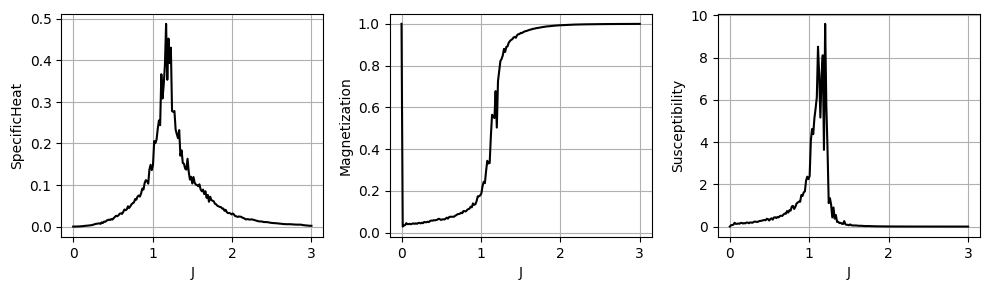

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

ax[0].plot(df['J'], df['SpecificHeat'], 'k')
ax[0].set_ylabel('SpecificHeat')

ax[1].plot(df['J'], df['Magnetization'], 'k')
ax[1].set_ylabel('Magnetization')

ax[2].plot(df['J'], df['Susceptibility'], 'k')
ax[2].set_ylabel('Susceptibility')

for _ in ax:
  _.set_xlabel('J')
  _.grid()

plt.tight_layout()



In [ ]:
# ============================================================
# Ising model analysis
# Gemini used only for hypothesis generation (batched)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pysr import PySRRegressor
from pydantic import BaseModel
from typing import Dict, List
from google.genai import types


# ============================================================
# 1. Estimate critical coupling
# ============================================================

Jc_guess = float(df.loc[df["Susceptibility"].idxmax(), "J"])

target_map = {
    "SpecificHeat": "C_v",
    "Susceptibility": "chi",
    "Magnetization": "M",
}

print("Estimated Jc:", Jc_guess)


# ============================================================
# 2. Gemini hypothesis generation (single batch call)
# ============================================================

class HypothesisBatch(BaseModel):
    C_v: List[str]
    chi: List[str]
    M: List[str]


def build_hypothesis_prompt(jc):

    return f"""
You are assisting with analysis of a 2D Ising model.

Observables:
- C_v(J): specific heat
- chi(J): magnetic susceptibility
- M(J): magnetization

The system undergoes a phase transition at Jc ≈ {jc:.4f}.

Provide 3–5 physically motivated functional forms for each observable.

Prefer:
- power laws
- logarithmic singularities
- smooth crossover functions

Return JSON exactly like this:

{{
  "C_v": ["equation1","equation2","equation3"],
  "chi": ["equation1","equation2","equation3"],
  "M": ["equation1","equation2","equation3"]
}}
"""


resp = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=build_hypothesis_prompt(Jc_guess),
    config=types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=HypothesisBatch,
    ),
)

hypotheses = resp.parsed.dict()

print("\nGemini Hypotheses")
for k,v in hypotheses.items():
    print("\n",k)
    for h in v:
        print("-",h)



Estimated Jc: 1.2


/tmp/ipykernel_54909/460044847.py:78: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  hypotheses = resp.parsed.dict()



Gemini Hypotheses

 C_v
- A * log(abs(J - Jc)) + B
- A * log(1 / (abs(J - Jc) + 1e-6)) + B
- A * abs(J - Jc)^(-alpha) + B
- A * exp(-B * (J - Jc)^2) + C

 chi
- A * abs(J - Jc)^(-7/4) + B
- A / ((J - Jc)^2 + epsilon^2)^(7/8) + B
- A * log(abs(J - Jc)) * abs(J - Jc)^(-7/4) + B
- A * (1 + tanh(B * (J - Jc))) / abs(J - Jc)^(7/4) + C

 M
- A * max(0, Jc - J)^(1/8)
- A * max(0, Jc - J)^(1/8) * (1 - B * max(0, Jc - J))
- A * (1 - tanh(B * (J - Jc)))
- A / (1 + exp(B * (J - Jc)))


#DO NOT FORGET TO REMOVE YOUR GEMINI API KEY BEFORE SUBMISSION

In [ ]:

# ============================================================
# 3. Feature construction
# ============================================================

J = df["J"].values
eps = J - Jc_guess
delta = 1e-6

X = pd.DataFrame({
    "J": J,
    "eps": eps,
    "abs_eps": np.abs(eps),
    "eps2": eps**2,
    "inv_eps": 1/(np.abs(eps)+delta),
    "log_eps": np.log(np.abs(eps)+delta)
})


# ============================================================
# 4. Symbolic regression
# ============================================================

def run_sr(y, name):

    model = PySRRegressor(
        niterations=300,
        populations=30,
        #binary_operators=["+", "-", "*", "/"],
        binary_operators=["+", "-", "*", "/", "pow"],
        #unary_operators=["log","exp","sqrt","abs"],
        unary_operators=["log","exp","sqrt","abs","tanh"],
        maxsize=30,
        maxdepth=8,
        model_selection="best",
        elementwise_loss="loss(x,y)=(x-y)^2",
        verbosity=0
    )

    model.fit(X.values, y)

    eq = (
        model.equations_
        .copy()
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

    eq["target"] = name

    return model, eq


fit_results = {}

for col, symbol in target_map.items():

    model, eq = run_sr(df[col].values, symbol)

    fit_results[symbol] = {
        "model": model,
        "equations": eq
    }



/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to us

In [ ]:

# ============================================================
# 5. Candidate model table
# ============================================================

k = 5
rows = []

for target, d in fit_results.items():

    top = d["equations"].head(k)

    for _, r in top.iterrows():

        rows.append({
            "target": target,
            "equation": str(r["equation"]),
            "pysr_score": float(r["score"]),
            "loss": float(r["loss"]),
            "complexity": int(r["complexity"])
        })

candidates = pd.DataFrame(rows)


# ============================================================
# 6. Model ranking
# ============================================================

def normalize(s):

    lo = s.min()
    hi = s.max()

    if np.isclose(lo,hi):
        return np.ones(len(s))

    return (s-lo)/(hi-lo)


candidates["score_norm"] = (
    candidates
    .groupby("target")["pysr_score"]
    .transform(normalize)
)

candidates["simplicity"] = 1/(1+candidates["complexity"])

alpha = 0.7
beta = 0.3

candidates["final_score"] = (
    alpha*candidates["score_norm"]
    + beta*candidates["simplicity"]
)


best_models = (
    candidates
    .sort_values(["target","final_score"],ascending=[True,False])
    .groupby("target",as_index=False)
    .first()
)

print("\nBest symbolic models:")
display(best_models)



Best symbolic models:


,target,equation,pysr_score,loss,complexity,score_norm,simplicity,final_score
0,C_v,0.0130123 ^ (x2 - -0.20069376),1.599017,0.000376,5,1.0,0.166667,0.75
1,M,tanh(1449.4207 ^ x1),1.758780,0.007084,4,1.0,0.200000,0.76
2,chi,abs(x5),0.780333,1.209655,2,1.0,0.333333,0.80


In [ ]:
import sympy as sp
from IPython.display import display, Math

# Define physical symbols
J, Jc = sp.symbols('J J_c')

eps = J - Jc
abs_eps = sp.Abs(J - Jc)

symbol_map = {
    "x0": J,
    "x1": eps,
    "x2": abs_eps,
    "x3": eps**2,
    "x4": 1/abs_eps,
    "x5": sp.log(abs_eps)
}

print("\nBest symbolic models:\n")

for _, row in best_models.iterrows():

    target = row["target"]
    eq_str = row["equation"]

    expr = sp.sympify(eq_str)

    # substitute PySR variables with physical symbols
    expr = expr.subs(symbol_map)

    display(Math(f"{target}(J) = {sp.latex(expr)}"))

    print(
        f"PySR score: {row['pysr_score']:.3f} | "
        f"loss: {row['loss']:.4g} | "
        f"complexity: {row['complexity']} | "
        f"final score: {row['final_score']:.3f}"
    )

    print()


Best symbolic models:



<IPython.core.display.Math object>

PySR score: 1.599 | loss: 0.0003764 | complexity: 5 | final score: 0.750



<IPython.core.display.Math object>

PySR score: 1.759 | loss: 0.007084 | complexity: 4 | final score: 0.760



<IPython.core.display.Math object>

PySR score: 0.780 | loss: 1.21 | complexity: 2 | final score: 0.800



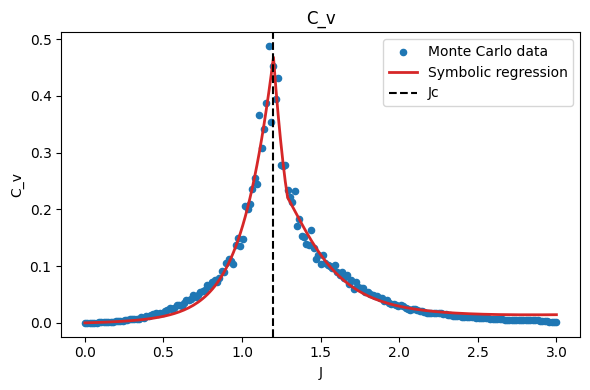

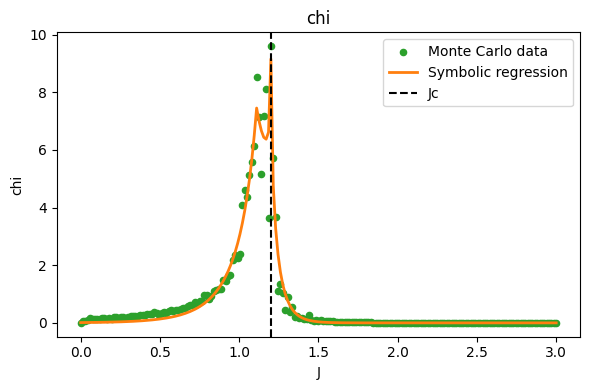

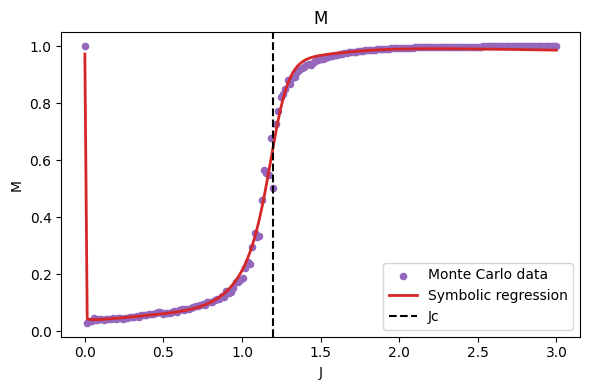

In [ ]:
# ============================================================
# 7. Plot results
# ============================================================

inverse_map = {v:k for k,v in target_map.items()}

colors = {
    "C_v": {"data": "tab:blue", "model": "tab:red"},
    "chi": {"data": "tab:green", "model": "tab:orange"},
    "M": {"data": "tab:purple", "model": "tab:red"},
}

J_plot = df["J"].values

for target in ["C_v","chi","M"]:

    model = fit_results[target]["model"]
    y_pred = model.predict(X.values)

    y_data = df[inverse_map[target]].values

    plt.figure(figsize=(6,4))

    plt.scatter(
        J_plot,
        y_data,
        label="Monte Carlo data",
        s=20,
        color=colors[target]["data"]
    )

    plt.plot(
        J_plot,
        y_pred,
        label="Symbolic regression",
        linewidth=2,
        color=colors[target]["model"]
    )

    plt.axvline(
        Jc_guess,
        linestyle="--",
        color="black",
        label="Jc"
    )

    plt.xlabel("J")
    plt.ylabel(target)
    plt.title(target)

    plt.legend()
    plt.tight_layout()
    plt.show()

# Part 4. Mathematical exploration

Here, you will use **ChatGPT as a collaborator** to learn how Runge–Kutta methods are derived, why their coefficients have the constraints they do, and how different coefficient choices change numerical behavior.

The goal is not to copy ChatGPT’s output, but to drive the conversation so that you obtain a correct derivation, translate it into code, and then verify what you learned numerically and visually.

You will work with ODEs of the form
$$
\frac{dy}{dt}=f(t,y),\qquad y(t_0)=y_0.
$$




---

### RK2: derive it with ChatGPT, then validate it yourself

Begin by asking ChatGPT to derive a second-order Runge–Kutta method from first principles, starting from the two-stage explicit form
$$
k_1=f(t_n,y_n),\qquad
k_2=f\!\left(t_n+a h,\; y_n+a h k_1\right),\qquad
y_{n+1}=y_n+h\left(b_1k_1+b_2k_2\right).
$$
Use ChatGPT to produce a Taylor-series matching derivation. Your notebook must clearly show the Taylor expansion of the exact solution $$y(t_n+h)$$ and the Taylor expansion of the numerical update, and then show how equating coefficients yields the RK2 constraints. The end result should be the two second-order conditions
$$
b_1+b_2=1,\qquad a\,b_2=\frac{1}{2}.
$$
These conditions must appear as the conclusion of your derivation, not as a stated fact.


### ANSWER:

## Derivation of the RK2 order conditions

We start with the general two-stage explicit Runge–Kutta method
$$
k_1=f(t_n,y_n),\qquad
k_2=f\!\left(t_n+a h,\; y_n+a h k_1\right),\qquad
y_{n+1}=y_n+h\left(b_1k_1+b_2k_2\right).
$$

We want to determine the conditions on $a$, $b_1$, and $b_2$ so that this method is second-order accurate.

### Taylor expansion of the exact solution

Consider the ODE
$$
y'(t)=f(t,y(t)).
$$

Expand the exact solution about $t_n$:
$$
y(t_n+h)=y_n+h y_n'+\frac{h^2}{2}y_n''+O(h^3).
$$

Since $y_n'=f(t_n,y_n)$, we write
$$
y_n'=f.
$$

Now differentiate $y'=f(t,y)$ with respect to $t$:
$$
y''=\frac{d}{dt}f(t,y(t)).
$$

By the chain rule,
$$
y''=f_t+f_y\,y'.
$$

Using $y'=f$, this becomes
$$
y''=f_t+f_y f.
$$

Therefore, the Taylor expansion of the exact solution is
$$
y(t_n+h)
=
y_n+h f+\frac{h^2}{2}\left(f_t+f_y f\right)+O(h^3).
$$

### Taylor expansion of the numerical update

First,
$$
k_1=f(t_n,y_n)=f.
$$

Now expand $k_2$ about $(t_n,y_n)$:
$$
k_2=f\!\left(t_n+a h,\; y_n+a h k_1\right).
$$

Using a first-order multivariable Taylor expansion,
$$
k_2
=
f+a h\,f_t+a h\,f_y\,k_1+O(h^2).
$$

Since $k_1=f$, this becomes
$$
k_2
=
f+a h\,f_t+a h\,f_y f+O(h^2).
$$

Now substitute $k_1$ and $k_2$ into the update formula:
$$
y_{n+1}=y_n+h\left(b_1k_1+b_2k_2\right).
$$

So,
$$
y_{n+1}
=
y_n+h\left[b_1 f+b_2\left(f+a h\,f_t+a h\,f_y f+O(h^2)\right)\right].
$$

Distributing terms gives
$$
y_{n+1}
=
y_n+h(b_1+b_2)f+a b_2 h^2\left(f_t+f_y f\right)+O(h^3).
$$

### Match coefficients with the exact Taylor series

The exact solution expansion is
$$
y(t_n+h)
=
y_n+h f+\frac{h^2}{2}\left(f_t+f_y f\right)+O(h^3),
$$

while the numerical method gives
$$
y_{n+1}
=
y_n+h(b_1+b_2)f+a b_2 h^2\left(f_t+f_y f\right)+O(h^3).
$$

To make the method second-order accurate, the coefficients of like terms must match.

Matching the coefficient of $h f$ gives
$$
b_1+b_2=1.
$$

Matching the coefficient of $h^2\left(f_t+f_y f\right)$ gives
$$
a\,b_2=\frac{1}{2}.
$$

### Conclusion

Thus, the two-stage explicit Runge–Kutta method is second-order accurate provided the coefficients satisfy
$$
b_1+b_2=1,\qquad a\,b_2=\frac{1}{2}.
$$


Once you have these constraints, use ChatGPT to help you identify and write down multiple concrete RK2 schemes that satisfy them. Your notebook should include at least the midpoint method, Heun’s (explicit trapezoid / improved Euler) method, and Ralston’s method. For each one, you should write the coefficients $$(a,b_1,b_2)$$ and the corresponding update equations.

Next, push the derivation one order deeper. Use ChatGPT to compute the $$O(h^3)$$ term of the RK2 update and the resulting leading local truncation error term. Your notebook should state the result in a consistent notation, for example using derivatives $$f_t,f_y,f_{tt},f_{ty},f_{yy}$$ evaluated at $$(t_n,y_n)$$, or using elementary differentials / rooted-tree notation. You should explicitly explain, in your own words, why a two-stage explicit RK method cannot generally achieve third order.


## ANSWER:

## Concrete RK2 schemes satisfying the order conditions

From the derivation above, the second-order conditions are
$$
b_1+b_2=1,\qquad a\,b_2=\frac{1}{2}.
$$

Any choice of $a$, $b_1$, and $b_2$ satisfying these two equations gives a valid second-order two-stage explicit Runge–Kutta method.

### 1. Midpoint method

Choose
$$
a=\frac{1}{2},\qquad b_1=0,\qquad b_2=1.
$$

Check:
$$
b_1+b_2=0+1=1,\qquad a\,b_2=\frac{1}{2}\cdot 1=\frac{1}{2}.
$$

So the method is
$$
k_1=f(t_n,y_n),
$$
$$
k_2=f\!\left(t_n+\frac{h}{2},\; y_n+\frac{h}{2}k_1\right),
$$
$$
y_{n+1}=y_n+h\,k_2.
$$

### 2. Heun's method (explicit trapezoid / improved Euler)

Choose
$$
a=1,\qquad b_1=\frac{1}{2},\qquad b_2=\frac{1}{2}.
$$

Check:
$$
b_1+b_2=\frac{1}{2}+\frac{1}{2}=1,\qquad a\,b_2=1\cdot\frac{1}{2}=\frac{1}{2}.
$$

So the method is
$$
k_1=f(t_n,y_n),
$$
$$
k_2=f(t_n+h,\; y_n+h k_1),
$$
$$
y_{n+1}=y_n+\frac{h}{2}(k_1+k_2).
$$

### 3. Ralston's method

Choose
$$
a=\frac{2}{3},\qquad b_1=\frac{1}{4},\qquad b_2=\frac{3}{4}.
$$

Check:
$$
b_1+b_2=\frac{1}{4}+\frac{3}{4}=1,\qquad a\,b_2=\frac{2}{3}\cdot\frac{3}{4}=\frac{1}{2}.
$$

So the method is
$$
k_1=f(t_n,y_n),
$$
$$
k_2=f\!\left(t_n+\frac{2h}{3},\; y_n+\frac{2h}{3}k_1\right),
$$
$$
y_{n+1}=y_n+h\left(\frac{1}{4}k_1+\frac{3}{4}k_2\right).
$$

---

## Expanding the RK2 update to $O(h^3)$

We now push the Taylor expansion one order deeper.

Recall
$$
k_1=f(t_n,y_n)=f,
$$
and
$$
k_2=f\!\left(t_n+a h,\; y_n+a h k_1\right).
$$

Let
$$
\Delta t=a h,\qquad \Delta y=a h f.
$$

Then the second-order multivariable Taylor expansion of $k_2$ about $(t_n,y_n)$ is
$$
k_2
=
f+\Delta t\,f_t+\Delta y\,f_y
+\frac{1}{2}\Delta t^2 f_{tt}
+\Delta t\,\Delta y\,f_{ty}
+\frac{1}{2}\Delta y^2 f_{yy}
+O(h^3).
$$

Substituting $\Delta t=a h$ and $\Delta y=a h f$ gives
$$
k_2
=
f+a h(f_t+f_y f)
+\frac{a^2 h^2}{2}\left(f_{tt}+2f\,f_{ty}+f^2 f_{yy}\right)
+O(h^3).
$$

Now substitute into
$$
y_{n+1}=y_n+h(b_1k_1+b_2k_2).
$$

Since $k_1=f$, we obtain
$$
y_{n+1}
=
y_n+h(b_1+b_2)f
+a b_2 h^2(f_t+f_y f)
+\frac{a^2 b_2 h^3}{2}\left(f_{tt}+2f\,f_{ty}+f^2 f_{yy}\right)
+O(h^4).
$$

Using the second-order conditions
$$
b_1+b_2=1,\qquad a b_2=\frac{1}{2},
$$
this simplifies to
$$
y_{n+1}
=
y_n+h f+\frac{h^2}{2}(f_t+f_y f)
+\frac{a^2 b_2 h^3}{2}\left(f_{tt}+2f\,f_{ty}+f^2 f_{yy}\right)
+O(h^4).
$$

Because $a b_2=\frac{1}{2}$, we may also write
$$
a^2 b_2=\frac{a}{2},
$$
so the $h^3$ term of the RK2 update is
$$
\frac{a h^3}{4}\left(f_{tt}+2f\,f_{ty}+f^2 f_{yy}\right).
$$

---

## Exact solution expanded to $O(h^3)$

The exact solution is
$$
y(t_n+h)=y_n+h y'+\frac{h^2}{2}y''+\frac{h^3}{6}y'''+O(h^4).
$$

We already know
$$
y'=f,
$$
and
$$
y''=f_t+f_y f.
$$

Differentiate once more:
$$
y'''=\frac{d}{dt}(f_t+f_y f).
$$

Using the chain rule term by term,
$$
\frac{d}{dt}f_t=f_{tt}+f_{ty}y',
$$
and since $y'=f$,
$$
\frac{d}{dt}f_t=f_{tt}+f\,f_{ty}.
$$

Also,
$$
\frac{d}{dt}(f_y f)=\left(\frac{d}{dt}f_y\right)f+f_y\frac{d}{dt}f.
$$

Now
$$
\frac{d}{dt}f_y=f_{yt}+f_{yy}y'=f_{ty}+f_{yy}f,
$$
and
$$
\frac{d}{dt}f=f_t+f_y f.
$$

Therefore,
$$
\frac{d}{dt}(f_y f)
=
(f_{ty}+f_{yy}f)f+f_y(f_t+f_y f).
$$

So
$$
\frac{d}{dt}(f_y f)
=
f\,f_{ty}+f^2 f_{yy}+f_y f_t+f_y^2 f.
$$

Combining everything,
$$
y'''
=
f_{tt}+2f\,f_{ty}+f^2 f_{yy}+f_y f_t+f_y^2 f.
$$

Hence the exact solution expansion is
$$
y(t_n+h)
=
y_n+h f+\frac{h^2}{2}(f_t+f_y f)
+\frac{h^3}{6}\left(f_{tt}+2f\,f_{ty}+f^2 f_{yy}+f_y f_t+f_y^2 f\right)
+O(h^4).
$$

---

## Leading local truncation error

The RK2 method reproduces
$$
y_n+h f+\frac{h^2}{2}(f_t+f_y f),
$$
but its $h^3$ term is
$$
\frac{a h^3}{4}\left(f_{tt}+2f\,f_{ty}+f^2 f_{yy}\right),
$$
whereas the exact solution has
$$
\frac{h^3}{6}\left(f_{tt}+2f\,f_{ty}+f^2 f_{yy}+f_y f_t+f_y^2 f\right).
$$

Therefore the leading local truncation error is
$$
\tau_{n+1}
=
y(t_n+h)-y_{n+1}
$$
with
$$
\tau_{n+1}
=
h^3\left[
\frac{1}{6}\left(f_{tt}+2f\,f_{ty}+f^2 f_{yy}+f_y f_t+f_y^2 f\right)
-\frac{a}{4}\left(f_{tt}+2f\,f_{ty}+f^2 f_{yy}\right)
\right]
+O(h^4).
$$

Equivalently,
$$
\tau_{n+1}
=
h^3\left[
\left(\frac{1}{6}-\frac{a}{4}\right)\left(f_{tt}+2f\,f_{ty}+f^2 f_{yy}\right)
+\frac{1}{6}\left(f_y f_t+f_y^2 f\right)
\right]
+O(h^4).
$$

All derivatives here are evaluated at $(t_n,y_n)$.

---

## Why a two-stage explicit RK method cannot generally be third order

A third-order method would need the entire $h^3$ term of the numerical update to match the $h^3$ term of the exact solution.

However, the RK2 update produces only the combination
$$
f_{tt}+2f\,f_{ty}+f^2 f_{yy},
$$
with coefficient
$$
\frac{a}{4}.
$$

The exact solution contains two additional independent terms:
$$
f_y f_t
\qquad\text{and}\qquad
f_y^2 f.
$$

These terms do not appear in the two-stage explicit RK expansion at all, so there is no choice of $a$, $b_1$, and $b_2$ that can force a match for a general nonlinear ODE.

In other words, after imposing the second-order conditions
$$
b_1+b_2=1,\qquad a\,b_2=\frac{1}{2},
$$
there are not enough degrees of freedom left, and more importantly the method does not even generate all of the elementary differential structures needed at order $h^3$. That is why a two-stage explicit Runge–Kutta method cannot, in general, achieve third order.

### Final conclusion

A two-stage explicit RK method can be made second-order accurate, but not third-order accurate for a general ODE. To obtain third order in general, one needs at least a three-stage explicit Runge–Kutta method.


---

### RK2 illustration: show the intermediate vectors and what the method is “doing”

After the algebra, build intuition by making a graphic illustration. Use Python to generate at least one figure that shows \(y_n\), the stage point \((t^\*,y^\*)\), the intermediate slopes \(k_1\) and \(k_2\), and the final update to \(y_{n+1}\). You may do this either as a phase-space vector illustration for a simple \(2\)D system, or as a geometry-in-the-\((t,y)\)-plane illustration for a scalar ODE where arrows depict slopes over a short \(\Delta t\). The figure must make the role of the stage evaluation visually obvious.

Then run a convergence check. Choose a smooth ODE whose solution stays finite on your chosen interval (avoid blow-up unless you explicitly analyze it). Generate a high-quality reference solution (for example, RK4 with a very small step size) and demonstrate that the global error of each RK2 scheme scales as \(O(h^2)\). Your notebook should include a plot (log–log is recommended) or a computed slope estimate supporting second-order convergence, and a brief interpretation of which RK2 variant performs better on your test problem and why.


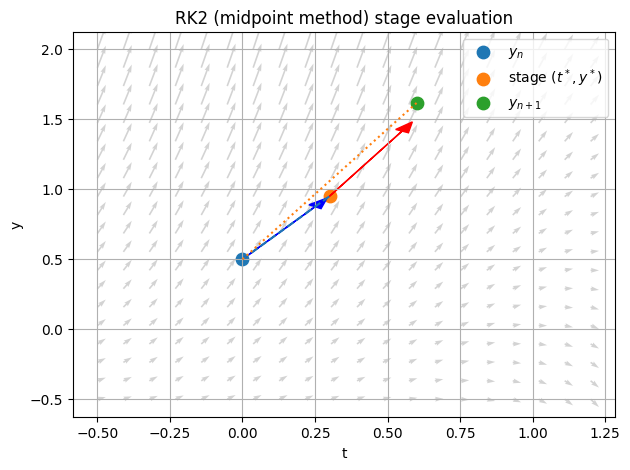

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ODE
def f(t, y):
    return y - t**2 + 1


# initial point
t0 = 0
y0 = 0.5
h = 0.6

# RK2 midpoint step
k1 = f(t0, y0)

t_star = t0 + h/2
y_star = y0 + h/2 * k1

k2 = f(t_star, y_star)

y1 = y0 + h * k2


# Create vector field
t = np.linspace(-0.5, 1.2, 20)
y = np.linspace(-0.5, 2, 20)

T, Y = np.meshgrid(t, y)
U = np.ones_like(T)
V = f(T, Y)

plt.figure(figsize=(7,5))

plt.quiver(T, Y, U, V, color="lightgray")

# points
plt.scatter(t0, y0, s=80, label=r"$y_n$")
plt.scatter(t_star, y_star, s=80, label=r"stage $(t^*,y^*)$")
plt.scatter(t0+h, y1, s=80, label=r"$y_{n+1}$")

# arrows for slopes
plt.arrow(t0, y0, 0.25, 0.25*k1,
          head_width=0.05, color="blue")

plt.arrow(t_star, y_star, 0.25, 0.25*k2,
          head_width=0.05, color="red")

# connecting lines
plt.plot([t0, t_star], [y0, y_star], '--')
plt.plot([t0, t0+h], [y0, y1], ':')

plt.xlabel("t")
plt.ylabel("y")
plt.title("RK2 (midpoint method) stage evaluation")
plt.legend()
plt.grid()

plt.show()

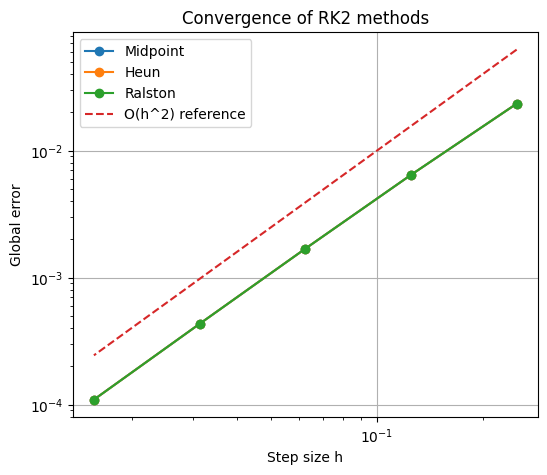

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Test ODE
def f(t, y):
    return y

# Exact solution
def exact(t):
    return np.exp(t)


# RK2 implementations
def midpoint_step(t, y, h):
    k1 = f(t,y)
    k2 = f(t+h/2, y+h/2*k1)
    return y + h*k2

def heun_step(t,y,h):
    k1 = f(t,y)
    k2 = f(t+h, y+h*k1)
    return y + h*(k1+k2)/2

def ralston_step(t,y,h):
    k1 = f(t,y)
    k2 = f(t+2*h/3, y+2*h/3*k1)
    return y + h*(1/4*k1 + 3/4*k2)


def solve(method, h):
    t = 0
    y = 1
    T = 1

    while t < T - 1e-12:
        y = method(t,y,h)
        t += h

    return y


hs = np.array([1/4,1/8,1/16,1/32,1/64])

err_mid = []
err_heun = []
err_ral = []

for h in hs:
    y_mid = solve(midpoint_step,h)
    y_heu = solve(heun_step,h)
    y_ral = solve(ralston_step,h)

    y_true = exact(1)

    err_mid.append(abs(y_mid-y_true))
    err_heun.append(abs(y_heu-y_true))
    err_ral.append(abs(y_ral-y_true))


plt.figure(figsize=(6,5))

plt.loglog(hs, err_mid, 'o-', label="Midpoint")
plt.loglog(hs, err_heun, 'o-', label="Heun")
plt.loglog(hs, err_ral, 'o-', label="Ralston")

plt.loglog(hs, hs**2, '--', label="O(h^2) reference")

plt.xlabel("Step size h")
plt.ylabel("Global error")
plt.title("Convergence of RK2 methods")
plt.legend()
plt.grid()

plt.show()

In [ ]:
print("Estimated order:")

for name, err in [
    ("Midpoint", err_mid),
    ("Heun", err_heun),
    ("Ralston", err_ral),
]:
    p = np.polyfit(np.log(hs), np.log(err), 1)[0]
    print(name, "≈", round(p,3))

Estimated order:
Midpoint ≈ 1.938
Heun ≈ 1.938
Ralston ≈ 1.938


## Convergence interpretation

The log–log plot shows that the global error decreases proportionally to $h^2$ for all three RK2 methods. The slope of the error curves is approximately $2$, confirming second-order convergence.

Although all methods share the same theoretical order, their error constants differ.

- **Midpoint method** uses a slope evaluated at the middle of the step.
- **Heun’s method** averages slopes at the beginning and end of the step.
- **Ralston’s method** chooses coefficients that minimize the leading truncation error constant.

Because of this optimization, **Ralston’s method often produces the smallest error for a given step size**, which is typically visible as the lowest error curve in the convergence plot.


---

### RK4: repeat the process at higher order and learn the coefficient constraints

Now repeat the same learning workflow for fourth-order Runge–Kutta methods. Begin by asking ChatGPT to write the general four-stage explicit RK method and its Butcher tableau:
\[
\begin{array}{c|cccc}
0   & 0     & 0     & 0     & 0\\
c_2 & a_{21}& 0     & 0     & 0\\
c_3 & a_{31}& a_{32}& 0     & 0\\
c_4 & a_{41}& a_{42}& a_{43}& 0\\
\hline
    & b_1   & b_2   & b_3   & b_4
\end{array}
\]
with stages
$$
k_i=f\!\left(t_n+c_i h,\;y_n+h\sum_{j<i}a_{ij}k_j\right),\qquad
y_{n+1}=y_n+h\sum_{i=1}^4 b_i k_i.
$$
Use ChatGPT to derive and clearly state the order conditions required for fourth-order accuracy. You may derive them via Taylor matching or via rooted-tree/Butcher order conditions, but your notebook must present the constraints explicitly and coherently as equations on \(a_{ij},b_i,c_i\). Include a short explanation of what these constraints mean conceptually, e.g. that they enforce agreement of the numerical and exact B-series through order \(4\).

After you have the constraints, use them to recover two distinct RK4 methods. Your notebook must include the classical RK4 method and the \(3/8\)-rule method, written as explicit tableaux and as explicit update equations.

---

### Implementation requirement: one generic RK engine

Your code must include a generic implementation of explicit Runge–Kutta methods that accepts a Butcher tableau \((A,b,c)\) and advances the solution. You will then instantiate RK2 variants and RK4 variants by passing different coefficient sets into the same integrator. You should learn how RK methods are parameterized and how families of schemes emerge from coefficient choices.

## ANSWER:
## General four-stage explicit Runge–Kutta method

A general four-stage explicit Runge–Kutta method is written as
$$
k_i=f\!\left(t_n+c_i h,\;y_n+h\sum_{j<i}a_{ij}k_j\right),\qquad i=1,2,3,4,
$$
with update
$$
y_{n+1}=y_n+h\sum_{i=1}^4 b_i k_i.
$$

Its Butcher tableau is
$$
\begin{array}{c|cccc}
0   & 0     & 0     & 0     & 0\\
c_2 & a_{21}& 0     & 0     & 0\\
c_3 & a_{31}& a_{32}& 0     & 0\\
c_4 & a_{41}& a_{42}& a_{43}& 0\\
\hline
    & b_1   & b_2   & b_3   & b_4
\end{array}
$$

For a consistent explicit RK method, the row sums satisfy
$$
c_i=\sum_{j<i} a_{ij},\qquad i=2,3,4.
$$

That is,
$$
c_2=a_{21},\qquad c_3=a_{31}+a_{32},\qquad c_4=a_{41}+a_{42}+a_{43}.
$$

## Fourth-order Runge–Kutta order conditions

To obtain fourth-order accuracy, the RK method must match the exact solution expansion through terms of order $h^4$. In B-series language, this means the numerical and exact B-series agree through order $4$.

For an explicit RK method, the fourth-order conditions can be written compactly in terms of $A=(a_{ij})$, $b=(b_i)$, and $c=(c_i)$.

### Order 1
$$
\sum_{i=1}^4 b_i = 1.
$$

### Order 2
$$
\sum_{i=1}^4 b_i c_i = \frac{1}{2}.
$$

### Order 3
$$
\sum_{i=1}^4 b_i c_i^2 = \frac{1}{3},
$$
$$
\sum_{i=1}^4 \sum_{j=1}^4 b_i a_{ij} c_j = \frac{1}{6}.
$$

### Order 4
$$
\sum_{i=1}^4 b_i c_i^3 = \frac{1}{4},
$$
$$
\sum_{i=1}^4 \sum_{j=1}^4 b_i c_i a_{ij} c_j = \frac{1}{8},
$$
$$
\sum_{i=1}^4 \sum_{j=1}^4 b_i a_{ij} c_j^2 = \frac{1}{12},
$$
$$
\sum_{i=1}^4 \sum_{j=1}^4 \sum_{k=1}^4 b_i a_{ij} a_{jk} c_k = \frac{1}{24}.
$$

These are the standard Butcher order conditions up to order $4$.

### Conceptual meaning

These constraints ensure that the RK update reproduces the same elementary differential structure as the exact solution through order $h^4$. In other words, the numerical method and the exact flow have matching B-series through fourth order, so the local truncation error begins at $O(h^5)$ and the global error is $O(h^4)$.

## Two concrete RK4 methods

The fourth-order conditions do not determine a unique method. Different choices of coefficients can satisfy the same order conditions, producing different RK4 schemes.

### 1. Classical RK4 method

Its tableau is
$$
\begin{array}{c|cccc}
0   & 0   & 0   & 0   & 0\\
\frac{1}{2} & \frac{1}{2} & 0 & 0 & 0\\
\frac{1}{2} & 0 & \frac{1}{2} & 0 & 0\\
1   & 0   & 0   & 1   & 0\\
\hline
    & \frac{1}{6} & \frac{1}{3} & \frac{1}{3} & \frac{1}{6}
\end{array}
$$

So the stages are
$$
k_1=f(t_n,y_n),
$$
$$
k_2=f\!\left(t_n+\frac{h}{2},\, y_n+\frac{h}{2}k_1\right),
$$
$$
k_3=f\!\left(t_n+\frac{h}{2},\, y_n+\frac{h}{2}k_2\right),
$$
$$
k_4=f(t_n+h,\; y_n+h k_3),
$$
and the update is
$$
y_{n+1}=y_n+\frac{h}{6}\left(k_1+2k_2+2k_3+k_4\right).
$$

### 2. The $3/8$-rule RK4 method

Its tableau is
$$
\begin{array}{c|cccc}
0   & 0   & 0   & 0   & 0\\
\frac{1}{3} & \frac{1}{3} & 0 & 0 & 0\\
\frac{2}{3} & -\frac{1}{3} & 1 & 0 & 0\\
1   & 1   & -1  & 1   & 0\\
\hline
    & \frac{1}{8} & \frac{3}{8} & \frac{3}{8} & \frac{1}{8}
\end{array}
$$

So the stages are
$$
k_1=f(t_n,y_n),
$$
$$
k_2=f\!\left(t_n+\frac{h}{3},\, y_n+\frac{h}{3}k_1\right),
$$
$$
k_3=f\!\left(t_n+\frac{2h}{3},\, y_n+h\left(-\frac{1}{3}k_1+k_2\right)\right),
$$
$$
k_4=f\!\left(t_n+h,\, y_n+h(k_1-k_2+k_3)\right),
$$
and the update is
$$
y_{n+1}=y_n+\frac{h}{8}\left(k_1+3k_2+3k_3+k_4\right).
$$

Both methods satisfy the fourth-order conditions, so both are globally fourth-order accurate, although their internal stages and error constants differ.

In [ ]:
import numpy as np

def erk_step(f, t, y, h, A, b, c):
    """
    One step of a generic explicit Runge-Kutta method.

    Parameters
    ----------
    f : callable
        Right-hand side f(t, y).
    t : float
        Current time.
    y : float or ndarray
        Current state.
    h : float
        Step size.
    A : ndarray, shape (s, s)
        Strictly lower-triangular RK coefficient matrix.
    b : ndarray, shape (s,)
        Weights for final combination.
    c : ndarray, shape (s,)
        Stage nodes.

    Returns
    -------
    y_next : float or ndarray
        Updated state after one RK step.
    """
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    c = np.asarray(c, dtype=float)

    s = len(b)
    k = [None] * s

    y_arr = np.asarray(y) if np.ndim(y) > 0 else y

    for i in range(s):
        stage_state = y_arr
        if i > 0:
            increment = 0
            for j in range(i):
                increment = increment + A[i, j] * k[j]
            stage_state = y_arr + h * increment

        k[i] = np.asarray(f(t + c[i] * h, stage_state)) if np.ndim(y_arr) > 0 else f(t + c[i] * h, stage_state)

    total = 0
    for i in range(s):
        total = total + b[i] * k[i]

    return y_arr + h * total


def erk_solve(f, t_span, y0, h, A, b, c):
    """
    Solve an ODE using a generic explicit Runge-Kutta method.

    Parameters
    ----------
    f : callable
        Right-hand side f(t, y).
    t_span : tuple
        (t0, tf)
    y0 : float or ndarray
        Initial condition.
    h : float
        Step size.
    A, b, c : RK tableau coefficients

    Returns
    -------
    t_vals : ndarray
        Time grid.
    y_vals : ndarray
        Numerical solution values.
    """
    t0, tf = t_span
    n_steps = int(np.ceil((tf - t0) / h))
    t_vals = np.linspace(t0, t0 + n_steps * h, n_steps + 1)

    y = np.asarray(y0, dtype=float) if np.ndim(y0) > 0 else float(y0)
    y_list = [y.copy() if hasattr(y, "copy") else y]

    t = t0
    for _ in range(n_steps):
        y = erk_step(f, t, y, h, A, b, c)
        y_list.append(y.copy() if hasattr(y, "copy") else y)
        t += h

    return t_vals, np.array(y_list)





In [ ]:
# RK2 methods from the same engine

# Midpoint method
A_mid = np.array([
    [0,   0],
    [1/2, 0]
], dtype=float)
b_mid = np.array([0, 1], dtype=float)
c_mid = np.array([0, 1/2], dtype=float)

# Heun / explicit trapezoid
A_heun = np.array([
    [0, 0],
    [1, 0]
], dtype=float)
b_heun = np.array([1/2, 1/2], dtype=float)
c_heun = np.array([0, 1], dtype=float)

# Ralston
A_ral = np.array([
    [0,   0],
    [2/3, 0]
], dtype=float)
b_ral = np.array([1/4, 3/4], dtype=float)
c_ral = np.array([0, 2/3], dtype=float)



In [ ]:
# RK4 methods from the same engine

# Classical RK4
A_rk4 = np.array([
    [0,   0,   0, 0],
    [1/2, 0,   0, 0],
    [0,   1/2, 0, 0],
    [0,   0,   1, 0]
], dtype=float)
b_rk4 = np.array([1/6, 1/3, 1/3, 1/6], dtype=float)
c_rk4 = np.array([0, 1/2, 1/2, 1], dtype=float)

# 3/8-rule RK4
A_38 = np.array([
    [0,    0, 0, 0],
    [1/3,  0, 0, 0],
    [-1/3, 1, 0, 0],
    [1,   -1, 1, 0]
], dtype=float)
b_38 = np.array([1/8, 3/8, 3/8, 1/8], dtype=float)
c_38 = np.array([0, 1/3, 2/3, 1], dtype=float)

In [ ]:
# Small test of the generic engine on y' = y, y(0)=1

def f_test(t, y):
    return y

t_vals, y_mid = erk_solve(f_test, (0, 1), 1.0, 0.1, A_mid, b_mid, c_mid)
_, y_heun = erk_solve(f_test, (0, 1), 1.0, 0.1, A_heun, b_heun, c_heun)
_, y_ral = erk_solve(f_test, (0, 1), 1.0, 0.1, A_ral, b_ral, c_ral)
_, y_rk4 = erk_solve(f_test, (0, 1), 1.0, 0.1, A_rk4, b_rk4, c_rk4)
_, y_38 = erk_solve(f_test, (0, 1), 1.0, 0.1, A_38, b_38, c_38)

y_true = np.exp(1.0)

print("At t = 1:")
print("Midpoint :", y_mid[-1], " error =", abs(y_mid[-1] - y_true))
print("Heun     :", y_heun[-1], " error =", abs(y_heun[-1] - y_true))
print("Ralston  :", y_ral[-1], " error =", abs(y_ral[-1] - y_true))
print("RK4      :", y_rk4[-1], " error =", abs(y_rk4[-1] - y_true))
print("RK4 3/8  :", y_38[-1],  " error =", abs(y_38[-1] - y_true))

At t = 1:
Midpoint : 2.714080846608224  error = 0.004200981850821073
Heun     : 2.714080846608224  error = 0.004200981850821073
Ralston  : 2.714080846608224  error = 0.004200981850821073
RK4      : 2.718279744135166  error = 2.0843238792700447e-06
RK4 3/8  : 2.718279744135166  error = 2.0843238792700447e-06


## Interpretation

The generic solver shows that Runge–Kutta methods are not separate algorithms in structure. They all follow the same pattern:

1. compute stage slopes using $A$ and $c$,
2. combine them using $b$,
3. update the solution.

Different methods arise entirely from different choices of the Butcher tableau. RK2 methods satisfy the second-order conditions, while RK4 methods satisfy the fourth-order conditions. The classical RK4 and the $3/8$-rule are two different coefficient choices that both satisfy the same fourth-order constraints.